In [2]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score

part1
- electric.csv 
1. 케라스 학습
2. scatter 와 예측선
3. 전기 생산량 4, 5 인 경우 전기 사용량 예측
4. 결정계수 (sklearn 이용)

In [3]:
eleDF = pd.read_csv('../../data/electric.csv', index_col='Unnamed: 0')
eleDF.head()

,전기생산량,전기사용량
0,3.52,2.48
1,2.58,2.27
2,3.31,2.47
3,4.07,2.77
4,4.62,2.98


In [4]:
x = eleDF['전기생산량'].values
y = eleDF['전기사용량'].values

## tensorflow

In [5]:
w = tf.Variable( 10.0, dtype=tf.float32 )
b = tf.Variable( 10.0, dtype=tf.float32)

lr = 0.01
optimizer = tf.keras.optimizers.Adam(learning_rate = lr)
for i in range(2000):
    with tf.GradientTape() as tape :
        hx = w * x + b
        cost = tf.reduce_mean((hx-y)**2)
    
    gradients = tape.gradient( cost, [w, b] )
    optimizer.apply_gradients( zip(gradients,[w,b]) )
    print('cost : ', cost.numpy())

print('최종 w : ', w.numpy(), '최종 b : ', b.numpy())

cost :  2152.8677
cost :  2148.2988
cost :  2143.735
cost :  2139.1765
cost :  2134.623
cost :  2130.0747
cost :  2125.532
cost :  2120.9941
cost :  2116.4617
cost :  2111.9353
cost :  2107.4143
cost :  2102.899
cost :  2098.3894
cost :  2093.8857
cost :  2089.3877
cost :  2084.8958
cost :  2080.41
cost :  2075.9304
cost :  2071.4565
cost :  2066.989
cost :  2062.5278
cost :  2058.0732
cost :  2053.6243
cost :  2049.1826
cost :  2044.7472
cost :  2040.3185
cost :  2035.8959
cost :  2031.4801
cost :  2027.0707
cost :  2022.6678
cost :  2018.2716
cost :  2013.8822
cost :  2009.4994
cost :  2005.1237
cost :  2000.7544
cost :  1996.3917
cost :  1992.0361
cost :  1987.6875
cost :  1983.3456
cost :  1979.0104
cost :  1974.6821
cost :  1970.3607
cost :  1966.0463
cost :  1961.7388
cost :  1957.4381
cost :  1953.1444
cost :  1948.8578
cost :  1944.578
cost :  1940.305
cost :  1936.0391
cost :  1931.7799
cost :  1927.5277
cost :  1923.2822
cost :  1919.044
cost :  1914.8125
cost :  1910.5879
co

In [6]:
def predFn( xd):
    hx = w * xd + b
    return hx.numpy()

predFn([4,5])

array([3.568921, 4.281712], dtype=float32)

1. 케라스 학습

In [7]:
dense = Dense(units=1, input_dim=1)
model = Sequential( [dense] ) # dense의 w와 b가 학습 대상
model.compile( loss='mse', optimizer=Adam(0.1))
model.fit(x, y, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - loss: 67.9895
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 60.1110
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 52.7327
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 45.8620
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 39.5047
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 33.6638
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 28.3399
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 23.5305
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 19.2299
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 15.4289
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 12.1144
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.2692
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 6.8722
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 4.8979
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.3171
Epoch 16/500
1/1 ━━

In [8]:
w, b = dense.get_weights()
print(w)
print(b)

[[0.41046304]]
[1.2573671]


In [9]:
y_pred_e = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


2. scatter 와 예측선

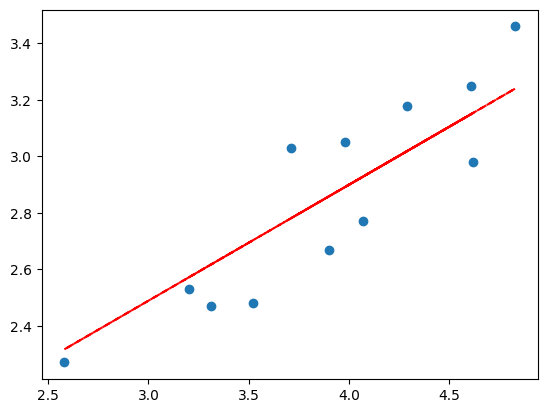

In [10]:
plt.scatter(x,y)
plt.plot(x, y_pred_e, 'r--')
plt.show()

3. 전기 생산량 4, 5 인 경우 전기 사용량 예측

In [11]:
model.predict(np.array([4]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[2.8992193]], dtype=float32)

In [12]:
model.predict(np.array([5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[3.3096824]], dtype=float32)

4. 결정계수 (sklearn 이용)

In [13]:
r2_score(y, y_pred_e)

0.7733852309954816

---

part2
- trees.csv
1. 케라스 학습
2. 예측값, 실제 값 plot
3. 11.1, 80 인 경우 volume 예측
4. 결정 계수

In [14]:
treeDF = pd.read_csv('../../data/trees.csv')
treeDF.head()

,Girth,Height,Volume
0,8.3,70,10.3
1,8.6,65,10.3
2,8.8,63,10.2
3,10.5,72,16.4
4,10.7,81,18.8


In [15]:
x1 = treeDF.iloc[:, :-1].values
y1 = treeDF.iloc[:, -1].values

In [16]:
x1.shape

(31, 2)

1. 케라스 학습

In [17]:
dense = Dense(units=1, input_dim=2)
print(dense(x1)) #  hx = matmul(x,w) + b
w, b = dense.get_weights() 
print(w)
print(b)

tf.Tensor(
[[ 4.8730464 ]
 [ 3.8886518 ]
 [ 3.4378796 ]
 [ 3.613391  ]
 [ 4.8579197 ]
 [ 5.0948877 ]
 [ 2.3323426 ]
 [ 3.7194066 ]
 [ 4.4187293 ]
 [ 3.5768714 ]
 [ 4.122075  ]
 [ 3.5884542 ]
 [ 3.5884542 ]
 [ 2.295823  ]
 [ 3.0067291 ]
 [ 2.2112007 ]
 [ 3.9065008 ]
 [ 3.775548  ]
 [ 1.1787033 ]
 [ 0.02860832]
 [ 2.0437279 ]
 [ 2.2094288 ]
 [ 1.0709152 ]
 [-0.30633736]
 [ 0.25045013]
 [ 0.15424633]
 [ 0.16582775]
 [-0.42747974]
 [-0.49874783]
 [-0.49874783]
 [-1.2728834 ]], shape=(31, 1), dtype=float32)
[[-0.7126779 ]
 [ 0.15411818]]
[0.]


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
dense = Dense(units=1, input_dim=2)
model = Sequential( [dense] ) # dense의 w와 b가 학습 대상
model.compile( loss='mse', optimizer=Adam(0.1))
model.fit(x1, y1, epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - loss: 1665.1056
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1057.2661
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 619.4968
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 348.0178
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 228.0072
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 228.6949
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 303.0536
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 397.6744
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 469.6772
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 497.8032
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 481.2679
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 431.9057
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 366.4153
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 301.0818
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - l

In [19]:
w, b = dense.get_weights() # 학습된 상태
print(w)
print(b)

[[ 5.010036  ]
 [-0.40769863]]
[-4.8759713]


2. 예측값, 실제 값 plot

In [20]:
model.predict(x1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[ 8.1684265],
       [11.7099285],
       [13.527334 ],
       [18.375105 ],
       [15.707823 ],
       [15.393435 ],
       [23.326317 ],
       [19.65703  ],
       [18.11954  ],
       [20.659037 ],
       [19.529245 ],
       [21.25334  ],
       [21.25334  ],
       [25.610243 ],
       [24.667063 ],
       [29.583792 ],
       [25.099108 ],
       [26.695425 ],
       [34.814915 ],
       [38.16981  ],
       [33.46404  ],
       [33.650646 ],
       [37.59985  ],
       [45.9303   ],
       [45.394814 ],
       [48.77406  ],
       [49.368366 ],
       [52.18778  ],
       [52.688786 ],
       [52.688786 ],
       [62.86099  ]], dtype=float32)

In [21]:
y1_pred = model.predict(x1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


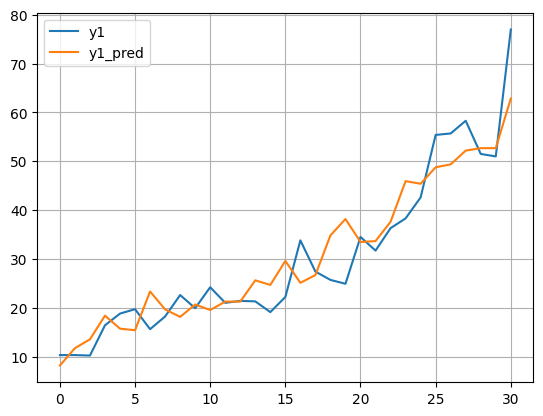

In [22]:
plt.plot(y1,  label='y1')
plt.plot(y1_pred, label='y1_pred')
plt.legend()
plt.grid(True)
plt.show()

3. 11.1, 80 인 경우 volume 예측

In [23]:
model.predict(np.array([[11.1, 80]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[18.11954]], dtype=float32)

4. 결정계수

In [24]:
r2_score(y1, y1_pred)

0.8776752899060757